In [1]:
from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval
from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val
from nuscenes.nuscenes import NuScenes
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import einops

In [2]:
data_root = '/home/mingdayang/mmdetection3d/data/nuscenes/'
nusc = NuScenes(version='v1.0-trainval', dataroot=data_root, verbose=True)
eval_set = 'val'
eval_detect_configs = config_factory('detection_cvpr_2019')

def find_sample_token(lidar_folder):
    print(lidar_folder.split('__'))
    timestamp_str = lidar_folder.split('__')[-1]
    print(timestamp_str)
    target_timestamp = int(timestamp_str)
    print(target_timestamp)

    # Initialize variables to track the closest sample
    closest_sample_token = None
    closest_time_diff = float('inf')

    # Iterate through all scenes
    for scene in nusc.scene:
        # Start from the first sample of the scene
        current_sample_token = scene['first_sample_token']

        while current_sample_token:
            # Retrieve the sample
            sample = nusc.get('sample', current_sample_token)

            # Calculate the time difference between the sample and the target timestamp
            time_diff = abs(sample['timestamp'] - target_timestamp)

            # Check for an exact match
            if sample['timestamp'] == target_timestamp:
                closest_sample_token = current_sample_token
                closest_time_diff = 0
                break

            # Update closest sample if this sample is closer
            if time_diff < closest_time_diff:
                closest_sample_token = current_sample_token
                closest_time_diff = time_diff

            # Move to the next sample in the scene
            current_sample_token = sample['next']

        # Break if we found an exact match
        if closest_time_diff == 0:
            break

    # Output the closest sample token and time difference
    if closest_sample_token:
        print(f"Closest sample token: {closest_sample_token}")
        print(f"Time difference (microseconds): {closest_time_diff}")
    else:
        print("No matching sample token found.")

    sample_token=closest_sample_token
    return sample_token

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 36.423 seconds.
Reverse indexing ...
Done reverse indexing in 20.0 seconds.


In [3]:
from random import sample


def figure_to_image(fig):
    fig.canvas.draw()  # Render the figure
    # Convert to a numpy array
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)  # Close the figure after conversion
    return image

def plot_singular_BEV_pointcloud(sample_token, nusc):
    """Plots the BEV point cloud for a given sample token.
    Blue: Ground truth
    Green: True Positive
    Red: False Positive
    
    """
    
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    sample_fig = nusc.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image = figure_to_image(sample_fig)
    ax.imshow(sample_image)
    ax.set_title(f"BEV Point Cloud for Sample Token: {sample_token}")
    ax.axis('off')
    ax.set_ylim(800, 106)
    ax.set_xlim(106, 800)
    plt.tight_layout()
    plt.close(sample_fig)
    plt.show()

def plot_bev_features(pts_bev_embed, channel=0, custom_titles=None, scaled=False, reduction='none'):
    fig, ax = plt.subplots(1, 3, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.93, wspace=0.02, hspace=0.005)
    if custom_titles is not None:
        fig.suptitle(custom_titles[0])
    else:
        fig.suptitle(f"BEV Feature Comparison for Channel {channel}")

    if reduction=='none':
        pts_bev_embed = pts_bev_embed
        channel = channel
    elif reduction=='mean':
        pts_bev_embed = [einops.reduce(bev_embed, 'b c h w -> b 1 h w', 'mean') for bev_embed in pts_bev_embed]
        channel = 0
    elif reduction=='max':
        pts_bev_embed = [einops.reduce(bev_embed, 'b c h w -> b 1 h w', 'max') for bev_embed in pts_bev_embed]
        channel = 0
    else:
        raise ValueError(f"Invalid reduction method: {reduction}. Choose from 'none', 'mean', or 'max'.")
    if scaled:
        pts = torch.stack(
            [pts_bev_embed[0, channel].detach().float().cpu() for pts_bev_embed in pts_bev_embed],
            dim=0
        )
        vmin = pts.min().item()
        vmax = pts.max().item()

    ax[0].imshow(pts_bev_embed[0][0, channel].cpu().numpy(), vmin=vmin if scaled else None, vmax=vmax if scaled else None, cmap='viridis')
    if custom_titles is not None:
        ax[0].set_title(custom_titles[1])
    else:
        ax[0].set_title(f"32 beams pts_bev for Sample Token")
    ax[0].axis('off')
  
    ax[1].imshow(pts_bev_embed[1][0, channel].cpu().numpy(), vmin=vmin if scaled else None, vmax=vmax if scaled else None, cmap='viridis')
    if custom_titles is not None:
        ax[1].set_title(custom_titles[2])
    else:
        ax[1].set_title(f"8 beams pts_bev for Sample Token")
    ax[1].axis('off')

    ax[2].imshow(pts_bev_embed[2][0, channel].cpu().numpy(), vmin=vmin if scaled else None, vmax=vmax if scaled else None, cmap='viridis')
    if custom_titles is not None:
        ax[2].set_title(custom_titles[3])
    else:
        ax[2].set_title(f"retrained 8 beams pts_bev for Sample Token")
    ax[2].axis('off')

    # plt.tight_layout()
    plt.show()

def plot_bev_features_unet(pts_bev_embed1, pts_bev_embed2, pts_bev_embed3=None, channel=0, custom_titles=None, scaled=False):
    fig, ax = plt.subplots(1, 3, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.93, wspace=0.02, hspace=0.005)
    if custom_titles is not None:
        fig.suptitle(custom_titles[0])
    else:
        fig.suptitle(f"BEV Feature Comparison for Channel {channel}")

    ax[0].imshow(pts_bev_embed1[0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[0].set_title(custom_titles[1])
    else:
        ax[0].set_title(f"32 beams pts_bev for Sample Token")
    ax[0].axis('off')

    if scaled:
        vmin = min(pts_bev_embed2[0, channel].min().item(), pts_bev_embed3[0, channel].min().item())
        vmax = max(pts_bev_embed2[0, channel].max().item(), pts_bev_embed3[0, channel].max().item())

    if scaled:
        ax[1].imshow(pts_bev_embed2[0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:
        ax[1].imshow(pts_bev_embed2[0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[1].set_title(custom_titles[2])
    else:
        ax[1].set_title(f"8 beams pts_bev for Sample Token")
    ax[1].axis('off')
    if scaled:
        ax[2].imshow(pts_bev_embed3[0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:
        ax[2].imshow(pts_bev_embed3[0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[2].set_title(custom_titles[3])
    else:
        ax[2].set_title(f"retrained 8 beams pts_bev for Sample Token")
    ax[2].axis('off')

    # plt.tight_layout()
    plt.show()

def plot_GT_pred_pointcloud(sample_token, nusc_1, nusc_2, nusc_3, custom_titles=None):
    """Plots the GT and predicted point cloud for a given sample token.
    Blue: Ground truth
    Green: True Positive
    Red: False Positive
    
    """
    
    fig, ax = plt.subplots(1, 3, figsize=(12,6),gridspec_kw={"wspace": 0.005, "hspace": 0.0})
    fig.subplots_adjust(left=0.001, right=0.999, bottom=0.001, top=0.90, wspace=0.005)
    if custom_titles is not None:
        fig.suptitle(custom_titles[0])
    else:
        fig.suptitle(f"GT vs Predicted Point Cloud for Sample Token: {sample_token}")

    sample_fig_gt = nusc_1.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_gt = figure_to_image(sample_fig_gt)
    ax[0].imshow(sample_image_gt)
    if custom_titles is not None:
        ax[0].set_title(custom_titles[1])
    else:
        ax[0].set_title(f"32 beams L")
    ax[0].axis('off')
    ax[0].set_ylim(800, 106)
    ax[0].set_xlim(106, 800)

    sample_fig_pred = nusc_2.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_pred = figure_to_image(sample_fig_pred)
    ax[1].imshow(sample_image_pred)
    if custom_titles is not None:
        ax[1].set_title(custom_titles[2])
    else:
        ax[1].set_title(f"8 beams L")
    ax[1].axis('off')
    ax[1].set_ylim(800, 106)
    ax[1].set_xlim(106, 800)

    sample_fig_retrained = nusc_3.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_retrained = figure_to_image(sample_fig_retrained)
    ax[2].imshow(sample_image_retrained)
    if custom_titles is not None:
        ax[2].set_title(custom_titles[3])
    else:
        ax[2].set_title(f"8 beams L retrained pts encoder")
    ax[2].axis('off')
    ax[2].set_ylim(800, 106)
    ax[2].set_xlim(106, 800)

    # plt.tight_layout()
    plt.close(sample_fig_pred)
    plt.close(sample_fig_gt)
    plt.close(sample_fig_retrained)
    plt.show()

def plot_detections_feature_maps(sample_token, nusc, pts_bev_embed, img_bev_embed, custom_titles=None, channel=10, scaled=True, reduction='none'):
    fig, ax = plt.subplots(2, 4, figsize=(16,10), gridspec_kw={"wspace": 0.02, "hspace": 0.02})
    fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.93, wspace=0.02, hspace=0.005)
    
    if custom_titles is not None:
        fig.suptitle(custom_titles[0], fontsize=12)
    else:
        fig.suptitle(f"Detections and BEV Feature Map for Sample Token: {sample_token}", fontsize=12)

    sample_fig_gt = nusc[0].main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_gt = figure_to_image(sample_fig_gt)
    ax[0, 0].imshow(sample_image_gt)
    if custom_titles is not None:
        ax[0, 0].set_title(custom_titles[1])
    else:
        ax[0, 0].set_title(f"32 beams L")
    ax[0, 0].axis('off')
    ax[0, 0].set_ylim(800, 106)
    ax[0, 0].set_xlim(106, 800)

    sample_fig_pred = nusc[1].main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_pred = figure_to_image(sample_fig_pred)
    ax[0, 1].imshow(sample_image_pred)
    if custom_titles is not None:
        ax[0, 1].set_title(custom_titles[2])
    else:
        ax[0, 1].set_title(f"8 beams L")
    ax[0, 1].axis('off')
    ax[0, 1].set_ylim(800, 106)
    ax[0, 1].set_xlim(106, 800)

    sample_fig_retrained = nusc[2].main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
    sample_image_retrained = figure_to_image(sample_fig_retrained)
    ax[0, 2].imshow(sample_image_retrained)
    if custom_titles is not None:
        ax[0, 2].set_title(custom_titles[3])
    else:
        ax[0, 2].set_title(f"8 beams L retrained pts encoder")
    ax[0, 2].axis('off')
    ax[0, 2].set_ylim(800, 106)
    ax[0, 2].set_xlim(106, 800)

    plt.close(sample_fig_pred)
    plt.close(sample_fig_gt)
    plt.close(sample_fig_retrained)

    if reduction=='none':
        pts_bev_embed = pts_bev_embed
        img_bev_embed = img_bev_embed
        channel = channel
    elif reduction=='mean':
        pts_bev_embed = [einops.reduce(bev_embed, 'b c h w -> b 1 h w', 'mean') for bev_embed in pts_bev_embed]
        img_bev_embed = einops.reduce(img_bev_embed, 'b c h w -> b 1 h w', 'mean')
        channel = 0
    elif reduction=='max':
        pts_bev_embed = [einops.reduce(bev_embed, 'b c h w -> b 1 h w', 'max') for bev_embed in pts_bev_embed]
        img_bev_embed = einops.reduce(img_bev_embed, 'b c h w -> b 1 h w', 'max')
        channel = 0
    else:
        raise ValueError(f"Invalid reduction method: {reduction}. Choose from 'none', 'mean', or 'max'.")
    if scaled:
        pts = torch.stack(
            [pts_bev_embed[0, channel].detach().float().cpu() for pts_bev_embed in pts_bev_embed],
            dim=0
        )
        vmin = pts.min().item()
        vmax = pts.max().item()

    ax[0, 3].axis('off')
    if custom_titles is not None:
        ax[0, 3].set_title(custom_titles[4])
    if img_bev_embed is not None:
        ax[0, 3].imshow(img_bev_embed[0, channel].cpu().numpy(), cmap='viridis')
    else:
        blank = np.zeros((200, 200, 4), dtype=np.float32)  # RGBA
        blank[..., 3] = 0.0  # fully transparent
        ax[0, 3].imshow(blank)
        
    if scaled:
        ax[1, 0].imshow(pts_bev_embed[0][0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:    
        ax[1, 0].imshow(pts_bev_embed[0][0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[1, 0].set_title(custom_titles[5])
    # else:
    #     ax[1, 0].set_title(f"32 beams pts_bev for Sample Token")
    ax[1, 0].axis('off')

    if scaled:
        ax[1, 1].imshow(pts_bev_embed[1][0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:
        ax[1, 1].imshow(pts_bev_embed[1][0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[1, 1].set_title(custom_titles[6])
    # else:
    #     ax[1, 1].set_title(f"8 beams pts_bev for Sample Token")
    ax[1, 1].axis('off')

    if scaled:
        ax[1, 2].imshow(pts_bev_embed[2][0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:
        ax[1, 2].imshow(pts_bev_embed[2][0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles is not None:
        ax[1, 2].set_title(custom_titles[7])
    # else:
    #     ax[1, 2].set_title(f"retrained 8 beams pts_bev for Sample Token")
    ax[1, 2].axis('off')

    if scaled:
        ax[1, 3].imshow(pts_bev_embed[3][0, channel].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='viridis')
    else:
        ax[1, 3].imshow(pts_bev_embed[3][0, channel].cpu().numpy(), cmap='viridis')
    if custom_titles[7] is not None:
        ax[1, 3].set_title(custom_titles[8])
    ax[1, 3].axis('off')

    # Add colorbar for the feature map shown in ax[1, 3]
    # fig.colorbar(mappable, ax=ax[1, 3], fraction=0.046, pad=0.04)

    # plt.tight_layout()
    plt.show()
 


In [4]:

def build_paths(path):
    results_file = f'{path}/pts_bbox/results_nusc.json'
    results_dir = f'{path}/pts_bbox/'
    return results_file, results_dir

# results_L_32_beams, results_dir_L_32_beams = build_paths('/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_nuscenes_val_32_beams')
results_L_8_beams, results_dir_L_8_beams = build_paths('/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_nuscenes_val_8_beams/')
# results_L_8_beams_retrained, results_dir_L_8_beams_retrained = build_paths('/home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_15/')
# results_L_8_beams_retrained_epoch_21, results_dir_L_8_beams_retrained_epoch_21 = build_paths('/home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_21/')
# results_unet_output, results_dir_unet_output = build_paths('/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/20-03-2026_eval_nuscenes_val_Unet_as_feature_map_LC_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss/')
# results_unet_only_output, results_dir_unet_only_output = build_paths('/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/21-03-2026_eval_nuscenes_val_Unet_as_feature_map_L_without_camera_detections_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss/')


# nusc_unet_only_output = DetectionEvalVis(
#     nusc = nusc,
#     config=eval_detect_configs,
#     result_path=results_unet_only_output,
#     eval_set=eval_set,
#     output_dir=results_dir_unet_only_output,
#     verbose=True)

# nusc_L_32_beams = DetectionEvalVis(
#     nusc = nusc,
#     config=eval_detect_configs,
#     result_path=results_L_32_beams,
#     eval_set=eval_set,
#     output_dir=results_dir_L_32_beams,
#     verbose=True)

# nusc_unet_output = DetectionEvalVis(
#     nusc = nusc,
#     config=eval_detect_configs,
#     result_path=results_unet_output,
#     eval_set=eval_set,
#     output_dir=results_dir_unet_output,
#     verbose=True)
    
# nusc_L_8_beams_retrained = DetectionEvalVis(
#     nusc = nusc,
#     config=eval_detect_configs,
#     result_path=results_L_8_beams_retrained,
#     eval_set=eval_set,
#     output_dir=results_dir_L_8_beams_retrained,
#     verbose=True)

nusc_L_8_beams = DetectionEvalVis(
    nusc = nusc,
    config=eval_detect_configs,
    result_path=results_L_8_beams,
    eval_set=eval_set,
    output_dir=results_dir_L_8_beams,
    verbose=True)

# nusc_L_8_beams_retrained_epoch_21 = DetectionEvalVis(
#     nusc = nusc,
#     config=eval_detect_configs,
#     result_path=results_L_8_beams_retrained_epoch_21,
#     eval_set=eval_set,
#     output_dir=results_dir_L_8_beams_retrained_epoch_21,
#     verbose=True)



Initializing nuScenes detection evaluation
Loaded results from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_nuscenes_val_8_beams//pts_bbox/results_nusc.json. Found detections for 6019 samples.
Loading annotations for val split from nuScenes version: v1.0-trainval


100%|██████████| 6019/6019 [00:19<00:00, 307.01it/s]


Loaded ground truth annotations for 6019 samples.
Filtering predictions
=> Original number of boxes: 1286612
=> After distance based filtering: 1286295
=> After LIDAR and RADAR points based filtering: 1286295
=> After bike rack filtering: 1286189
Filtering ground truth annotations
=> Original number of boxes: 187528
=> After distance based filtering: 134565
=> After LIDAR and RADAR points based filtering: 121871
=> After bike rack filtering: 121861


In [5]:
# main_vis_per_sample = nusc_L_32_beams.main_vis_per_sample

In [6]:
from nuscenes.utils.splits import val
# All validation scene names for v1.0-trainval
val_scene_names = set(val)
val_scenes = [scene for scene in nusc.scene if scene['name'] in val_scene_names]

scene_name = val_scenes[0]['name']   # or e.g. 'scene-0003'
scene = next(scene for scene in nusc.scene if scene['name'] == scene_name)

print(scene)

sample_tokens = []
sample_token = scene['first_sample_token']

while sample_token != '':
    sample_tokens.append(sample_token)
    sample_token = nusc.get('sample', sample_token)['next']

print(f'{scene_name}: {len(sample_tokens)} samples')
print(sample_tokens[:5])

{'token': 'e7ef871f77f44331aefdebc24ec034b7', 'log_token': '92af2609d31445e5a71b2d895376fed6', 'nbr_samples': 40, 'first_sample_token': 'fd8420396768425eabec9bdddf7e64b6', 'last_sample_token': '20684b77c01641e7a5ada48308a0b1e1', 'name': 'scene-0003', 'description': 'Parking lot, barrier, exit parking lot'}
scene-0003: 40 samples
['fd8420396768425eabec9bdddf7e64b6', '6eb8a3ff0abf4f3a9380a48f2a0b87ef', 'b10f0cd792b64d16a1a5e8349b20504c', '163b70e627854893b88575caf85a56ea', 'f56a544064a548a39a81f18cc8f633c5']


In [7]:
root_32_beams = '/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes'
root_8_beams = '/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_mini_nuscenes_8_beams'
root_retrained = '/home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_15/'
root_retrained_epoch_21 = '/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_21'
root_unet_output = '/home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_mini_nuscenes_val_LC_unet_save_output_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_quarter_baseline_mse_loss/'
lidar_folders = [f for f in os.listdir(root_retrained) if f.startswith('n')]
print("Found lidar folders:", lidar_folders)

lidar_folder = lidar_folders[20]

sample_token = find_sample_token(lidar_folder)

def get_pts_embed(lidar_folder, root_folder):
    pts_embed_path = os.path.join(root_folder, lidar_folder, 'vis_data.pt')
    if os.path.exists(pts_embed_path):
        data = torch.load(pts_embed_path)
        pts_bev_embed = data['ori_pts_bev_embed']
        print(f"Loaded pts_bev_embed from {pts_embed_path} with shape {pts_bev_embed.shape}")
        
        x = einops.rearrange(pts_bev_embed, 'b (h w) c -> b c h w', h=200, w=200)
        x = torch.flip(x, dims=[2])  # Flip the height dimension to correct orientation
        return x
    else:
        print(f"pts_bev_embed not found in {lidar_folder}")
        return None

def get_bev_prediction(lidar_folder, root_folder):
    bev_prediction_path = os.path.join(root_folder, lidar_folder, 'vis_data.pt')
    if os.path.exists(bev_prediction_path):
        data = torch.load(bev_prediction_path)
        bev_consumer_prediction = data['bev_consumer_prediction']
        img = data['ori_img_bev_embed']
        img = einops.rearrange(img, 'b (h w) c -> b c h w', h=200, w=200)
        pts = data['ori_pts_bev_embed']
        pts = einops.rearrange(pts, 'b (h w) c -> b c h w', h=200, w=200)
        print(f"Loaded bev_consumer_prediction from {bev_prediction_path} with shape {bev_consumer_prediction.shape}")
        
        x = torch.flip(bev_consumer_prediction, dims=[2])  # Flip the height dimension to correct orientation
        img = torch.flip(img, dims=[2])  # Flip the height dimension to correct orientation
        pts = torch.flip(pts, dims=[2])  # Flip the height dimension to correct orientation
        return x, img, pts
    else:
        print(f"bev_consumer_prediction not found in {lidar_folder}")
        return None

pts_bev_embed_retrained = get_pts_embed(lidar_folder, root_retrained)
pts_bev_embed_8_beams = get_pts_embed(lidar_folder, root_8_beams)
pts_bev_embed_32_beams = get_pts_embed(lidar_folder, root_32_beams)
pts_bev_embed_unet_output, img_bev_embed_unet_input, pts_bev_embed_unet_input = get_bev_prediction(lidar_folder, root_unet_output)
pts_bev_embed_retrained_epoch_21 = get_pts_embed(lidar_folder, root_retrained_epoch_21)



Found lidar folders: ['n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984242447730', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984234047134', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151604048025', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984238447571', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984245947391', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151611896734', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151612897588', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151622448916', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151622948227', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151607048933', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984248948287', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151608548020', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151621947928', 'n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151621047706', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984243446332', 'n015-2018-10-08-15-36-50+0800__LIDAR_TOP__15389

Loaded pts_bev_embed from /home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_15/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984251447166/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_mini_nuscenes_8_beams/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984251447166/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984251447166/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded bev_consumer_prediction from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_exper

Using from_file to load point cloud


/home/mingdayang/mmdetection3d/mmdet3d/unibev_plugin/datasets/detection_eval_custom.py:329: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  handles=[mpatches.Patch(color='b'), mpatches.Patch(color='g'), mpatches.Patch(color='r')])


Rendering sample token e6e877f31dd447199b56cae07f86daad


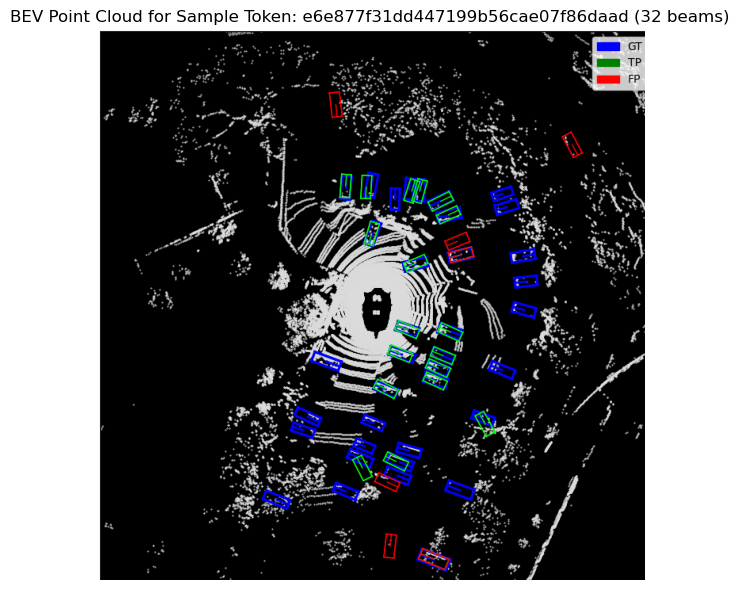

In [10]:
def plot_singular_BEV_pointcloud(sample_token, nusc, vis_num_beams=8, nsweeps=3):
    """Plots the BEV point cloud for a given sample token.
    Blue: Ground truth
    Green: True Positive
    Red: False Positive
    """
    
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    sensor_dict = {"visualize_num_beams": vis_num_beams, "num_beam_sensor": 32, "nsweeps": nsweeps}
    sample_fig = nusc.main_vis_per_sample(
        sample_token,
        conf_th=0.15,
        with_GT=True,
        display_legend=True,
        sensor_dict=sensor_dict
    )
    sample_image = figure_to_image(sample_fig)
    ax.imshow(sample_image)
    ax.set_title(f"BEV Point Cloud for Sample Token: {sample_token} ({vis_num_beams} beams)")
    ax.axis('off')
    ax.set_ylim(800, 106)
    ax.set_xlim(106, 800)
    plt.tight_layout()
    plt.close(sample_fig)
    plt.show()

plot_singular_BEV_pointcloud(sample_token, nusc_L_8_beams, vis_num_beams=32, nsweeps=3)

In [9]:
import cv2

image_path=f"/home/mingdayang/mmdetection3d/figures/pts_encoder_retraining_samples/samples/L_beams_24_dropped_sample_{sample_token}.jpg"
print(image_path)
img = cv2.imread(image_path)
plt.imshow(img)
plt.axis('off')

KeyboardInterrupt: 

NameError: name 'nusc_unet_output' is not defined

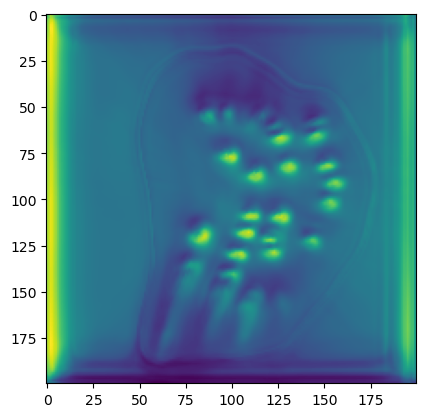

In [7]:
plt.imshow(pts_bev_embed_unet_output[0, 50].cpu().numpy())
plot_singular_BEV_pointcloud(sample_token, nusc_unet_output)

In [8]:
plt.imshow(img_bev_embed_input[0, 50].cpu().numpy())

NameError: name 'img_bev_embed_input' is not defined

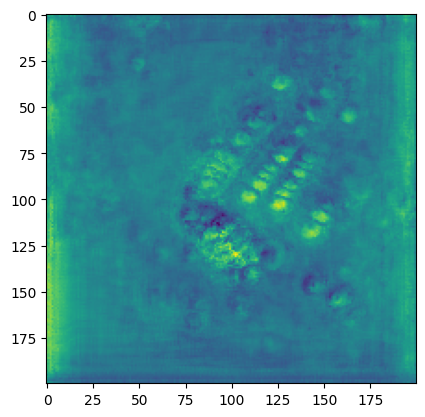

In [ ]:
plt.imshow(pts[0, 50].cpu().numpy())

Rendering sample token e6e877f31dd447199b56cae07f86daad


Rendering sample token e6e877f31dd447199b56cae07f86daad
Rendering sample token e6e877f31dd447199b56cae07f86daad


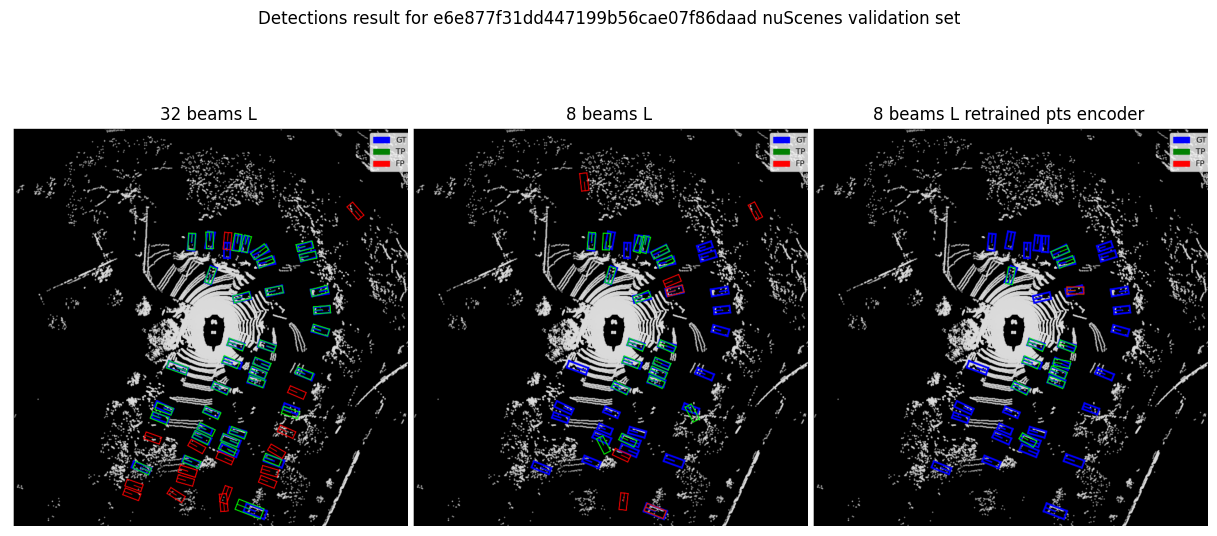

In [ ]:
# sample_token = sample_tokens[0]
# print(sample_token)
custom_titles = [
    f"Detections result for {sample_token} nuScenes validation set",
    "32 beams L",
    "8 beams L",
    "8 beams L retrained pts encoder"
]
plot_GT_pred_pointcloud(sample_token, 
                        nusc_1=nusc_L_32_beams, 
                        nusc_2=nusc_L_8_beams,
                        nusc_3=nusc_L_8_beams_retrained,
                        custom_titles=custom_titles)

Rendering sample token 9e7683e8586542a1b6032980c45f15ce
Rendering sample token 9e7683e8586542a1b6032980c45f15ce
Rendering sample token 9e7683e8586542a1b6032980c45f15ce


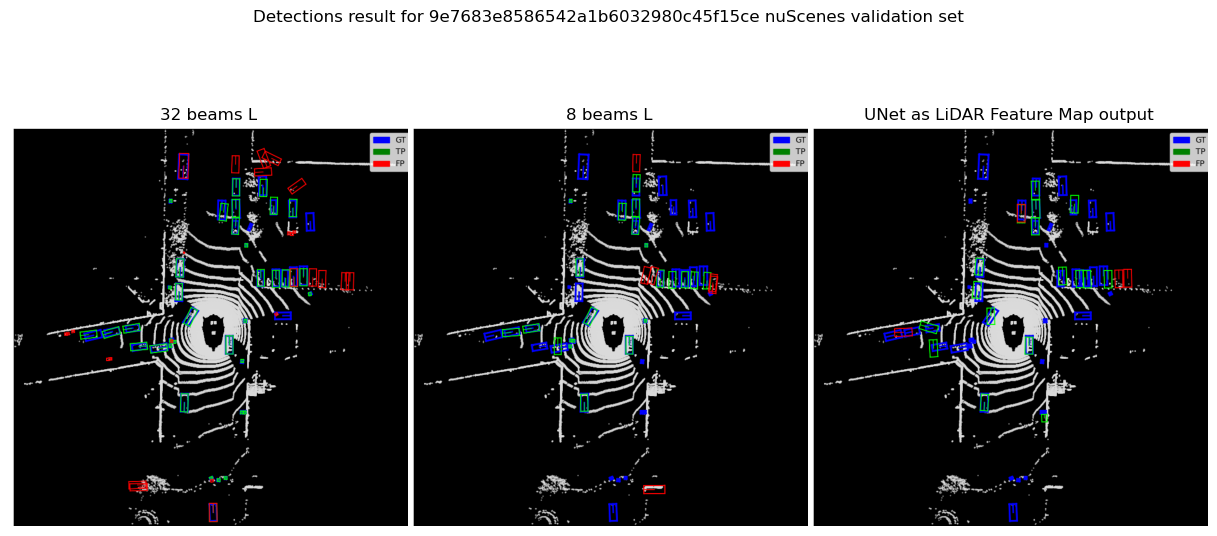

In [31]:
# sample_token = sample_tokens[0]
# print(sample_token)
custom_titles = [
    f"Detections result for {sample_token} nuScenes validation set",
    "32 beams L",
    "8 beams L",
    "UNet as LiDAR Feature Map output"
]
plot_GT_pred_pointcloud(sample_token, 
                        nusc_1=nusc_L_32_beams, 
                        nusc_2=nusc_L_8_beams,
                        nusc_3=nusc_unet_only_output,
                        custom_titles=custom_titles)

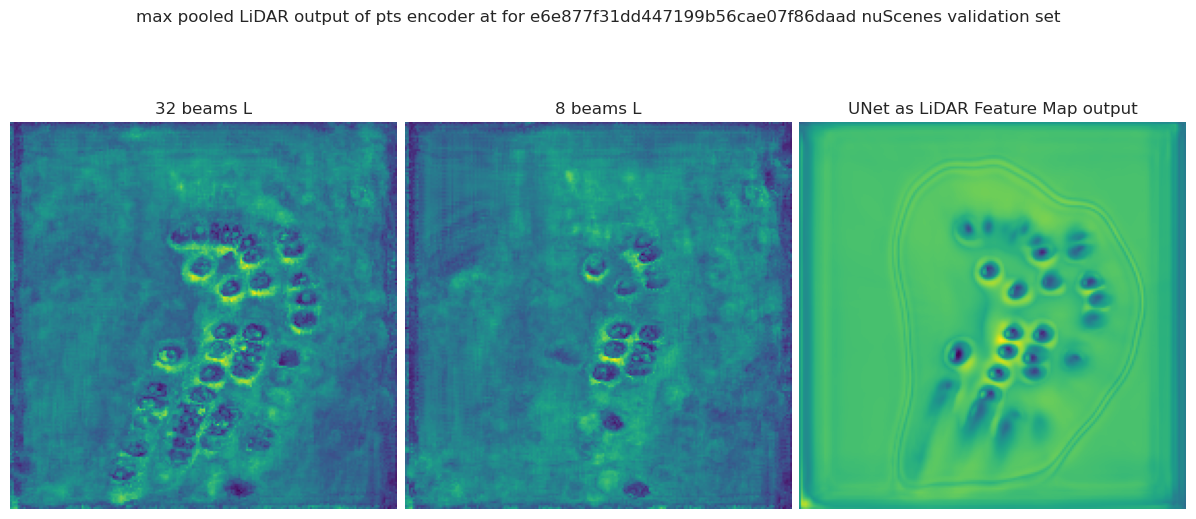

In [ ]:
channel = 50
custom_titles = [
    f"max pooled LiDAR output for {sample_token} nuScenes validation set",
    "32 beams L",
    "8 beams L",
    "UNet as LiDAR Feature Map output"
]

feature_maps = [
    pts_bev_embed_32_beams,
    pts_bev_embed_8_beams,
    pts_bev_embed_unet_output
]
plot_bev_features(feature_maps, channel=channel, custom_titles=custom_titles, reduction='max', scaled=False)

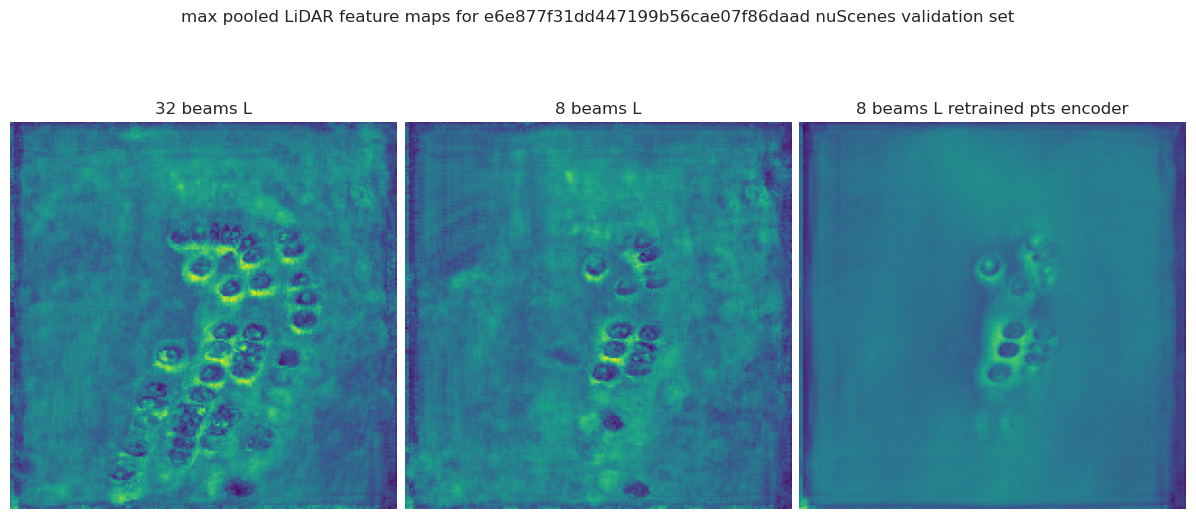

In [67]:
channel = 0
custom_titles = [
    f"max pooled LiDAR feature maps for {sample_token} nuScenes validation set",
    "32 beams L",
    "8 beams L",
    "8 beams L retrained pts encoder"
]

feature_maps = [
    pts_bev_embed_32_beams,
    pts_bev_embed_8_beams,
    pts_bev_embed_retrained
]

plot_bev_features(feature_maps, channel=channel, custom_titles=custom_titles, reduction='max', scaled=True)

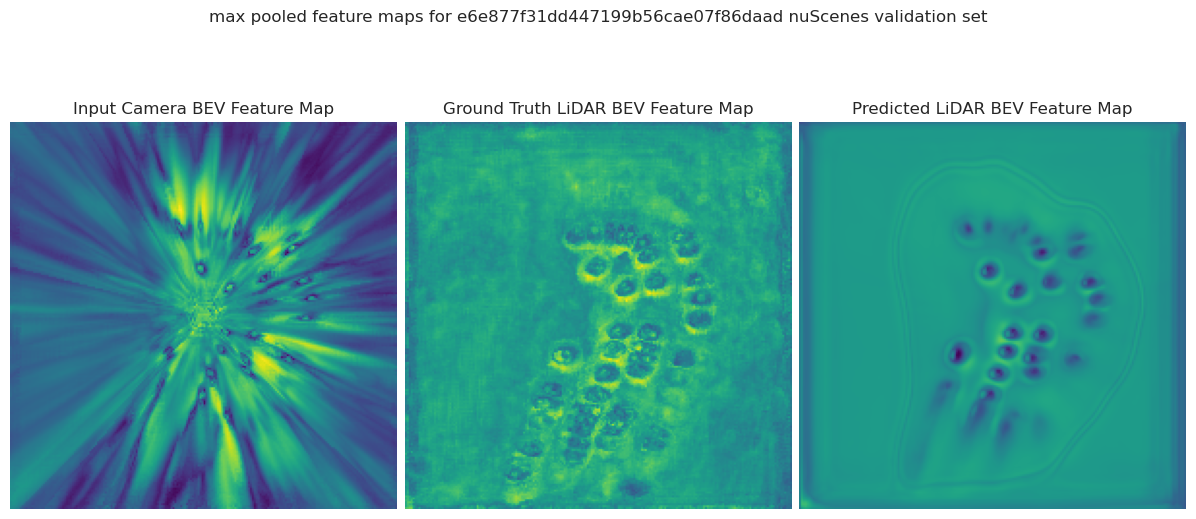

In [65]:
channel = 0
custom_titles = [
    f"max pooled feature maps for {sample_token} nuScenes validation set",
    "Input Camera BEV Feature Map",
    "Ground Truth LiDAR BEV Feature Map",
    "Predicted LiDAR BEV Feature Map"
]


plot_bev_features_unet(einops.reduce(img_bev_embed_unet_input, 'b c h w -> b 1 h w', 'max'), einops.reduce(pts_bev_embed_unet_input, 'b c h w -> b 1 h w', 'max'), einops.reduce(pts_bev_embed_unet_output, 'b c h w -> b 1 h w', 'max'), channel=channel, custom_titles=custom_titles, scaled=True)

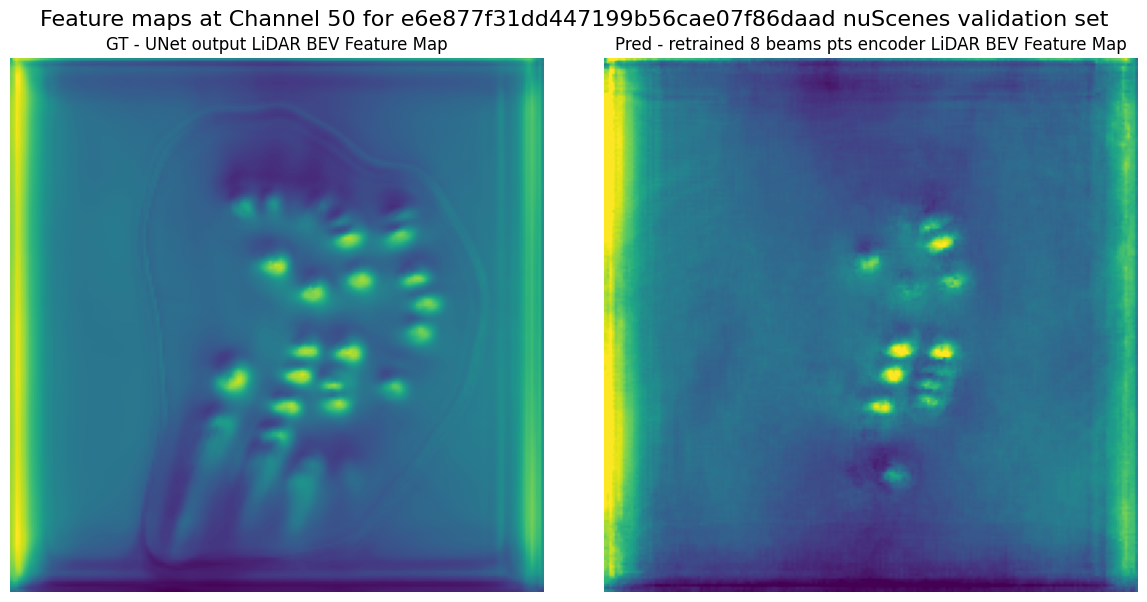

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

plt.suptitle(f"Feature maps at Channel {channel} for {sample_token} nuScenes validation set", fontsize=16)
ax[0].imshow(pts_bev_embed_unet_output[0, channel].cpu().numpy())
ax[0].set_title("GT - UNet output LiDAR BEV Feature Map")
ax[0].axis('off')

ax[1].imshow(pts_bev_embed_retrained[0, channel].cpu().numpy(), vmin=pts_bev_embed_unet_output[0, channel].min().item(), vmax=pts_bev_embed_unet_output[0, channel].max().item())
ax[1].set_title("Pred - retrained 8 beams pts encoder LiDAR BEV Feature Map")
ax[1].axis('off')
plt.show()

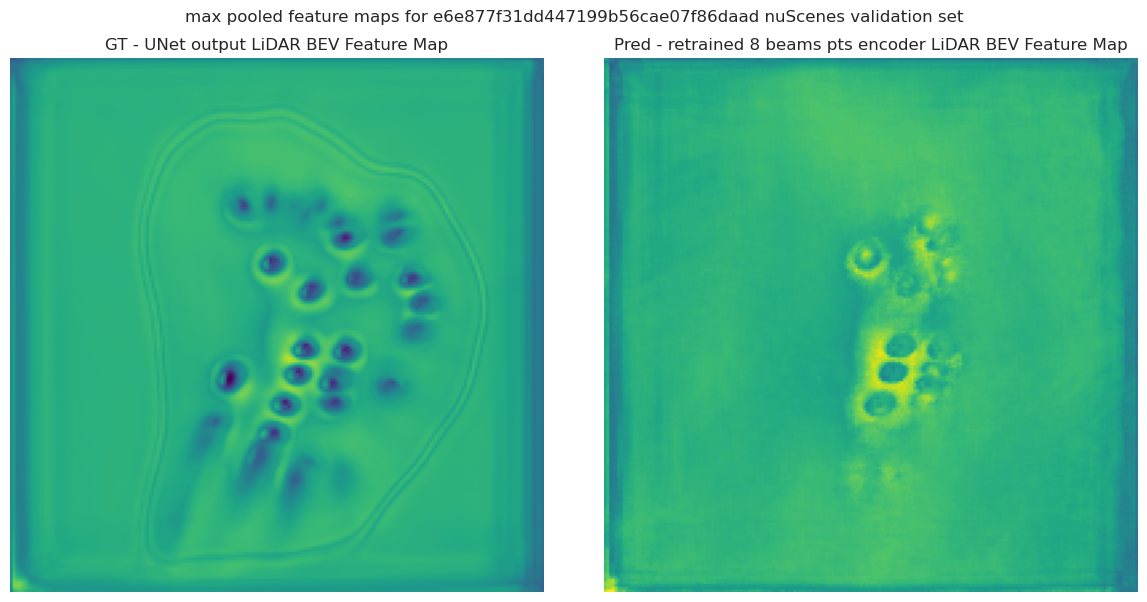

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

image_1 = einops.reduce(pts_bev_embed_unet_output, 'b c h w -> b 1 h w', 'max')[0,0].cpu().numpy()
image_2 = einops.reduce(pts_bev_embed_retrained, 'b c h w -> b 1 h w', 'max')[0,0].cpu().numpy()
vmin = min(image_1.min(), image_2.min())
vmax = max(image_1.max(), image_2.max())

plt.suptitle(f"max pooled feature maps for {sample_token} nuScenes validation set", fontsize=12)
ax[0].imshow(image_1, cmap='viridis', vmin=vmin, vmax=vmax)
ax[0].set_title("GT - UNet output LiDAR BEV Feature Map")
ax[0].axis('off')

ax[1].imshow(image_2, cmap='viridis', vmin=vmin, vmax=vmax)
ax[1].set_title("Pred - retrained 8 beams pts encoder LiDAR BEV Feature Map")
ax[1].axis('off')
plt.show()

['n015-2018-10-08-15-36-50+0800', 'LIDAR_TOP', '1538984241947812']
1538984241947812
1538984241947812
Closest sample token: b6c420c3a5bd4a219b1cb82ee5ea0aa7
Time difference (microseconds): 0
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_15/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984241947812/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_mini_nuscenes_8_beams/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984241947812/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/n015-2018-10-08-15-36-50+0800__

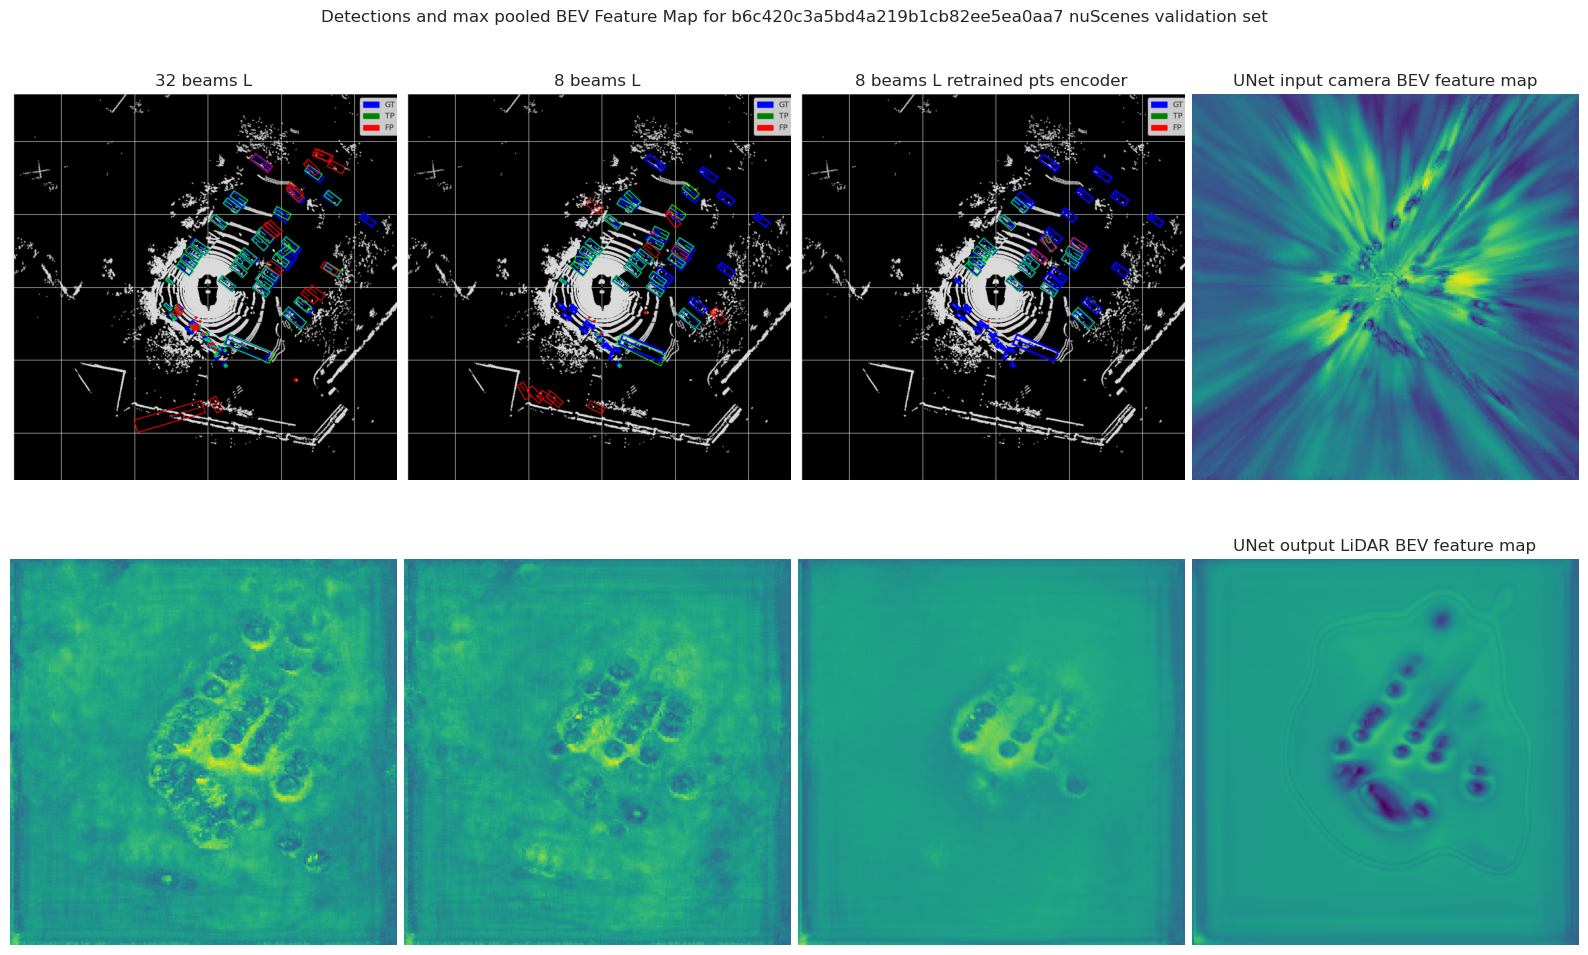

In [64]:
# Lidar folders chosen, 0, 2
lidar_folder = lidar_folders[40]
channel=10
sample_token = find_sample_token(lidar_folder)

pts_bev_embed_retrained = get_pts_embed(lidar_folder, root_retrained)
pts_bev_embed_8_beams = get_pts_embed(lidar_folder, root_8_beams)
pts_bev_embed_32_beams = get_pts_embed(lidar_folder, root_32_beams)
pts_bev_embed_unet_output, img_bev_embed_input, pts = get_bev_prediction(lidar_folder, root_unet_output)
pts_bev_embed_retrained_epoch_21 = get_pts_embed(lidar_folder, root_retrained_epoch_21)


plot_detections_feature_maps(sample_token, 
                            nusc=[nusc_L_32_beams, nusc_L_8_beams, nusc_L_8_beams_retrained], 
                            pts_bev_embed=[pts_bev_embed_32_beams, pts_bev_embed_8_beams, pts_bev_embed_retrained, pts_bev_embed_unet_output],
                            img_bev_embed=img_bev_embed_input,
                            scaled=True,
                            custom_titles=[
                                f"Detections and max pooled BEV Feature Map for {sample_token} nuScenes validation set",
                                "32 beams L",
                                "8 beams L",
                                "8 beams L retrained pts encoder",
                                "UNet input camera BEV feature map",
                                "",
                                "",
                                "",
                                "UNet output LiDAR BEV feature map"
                            ],
                            channel=channel,
                            reduction='max')


Rendering sample token 6402fd1ffaf041d0b9162bd92a7ba0a2
Rendering sample token 6402fd1ffaf041d0b9162bd92a7ba0a2
Rendering sample token 6402fd1ffaf041d0b9162bd92a7ba0a2


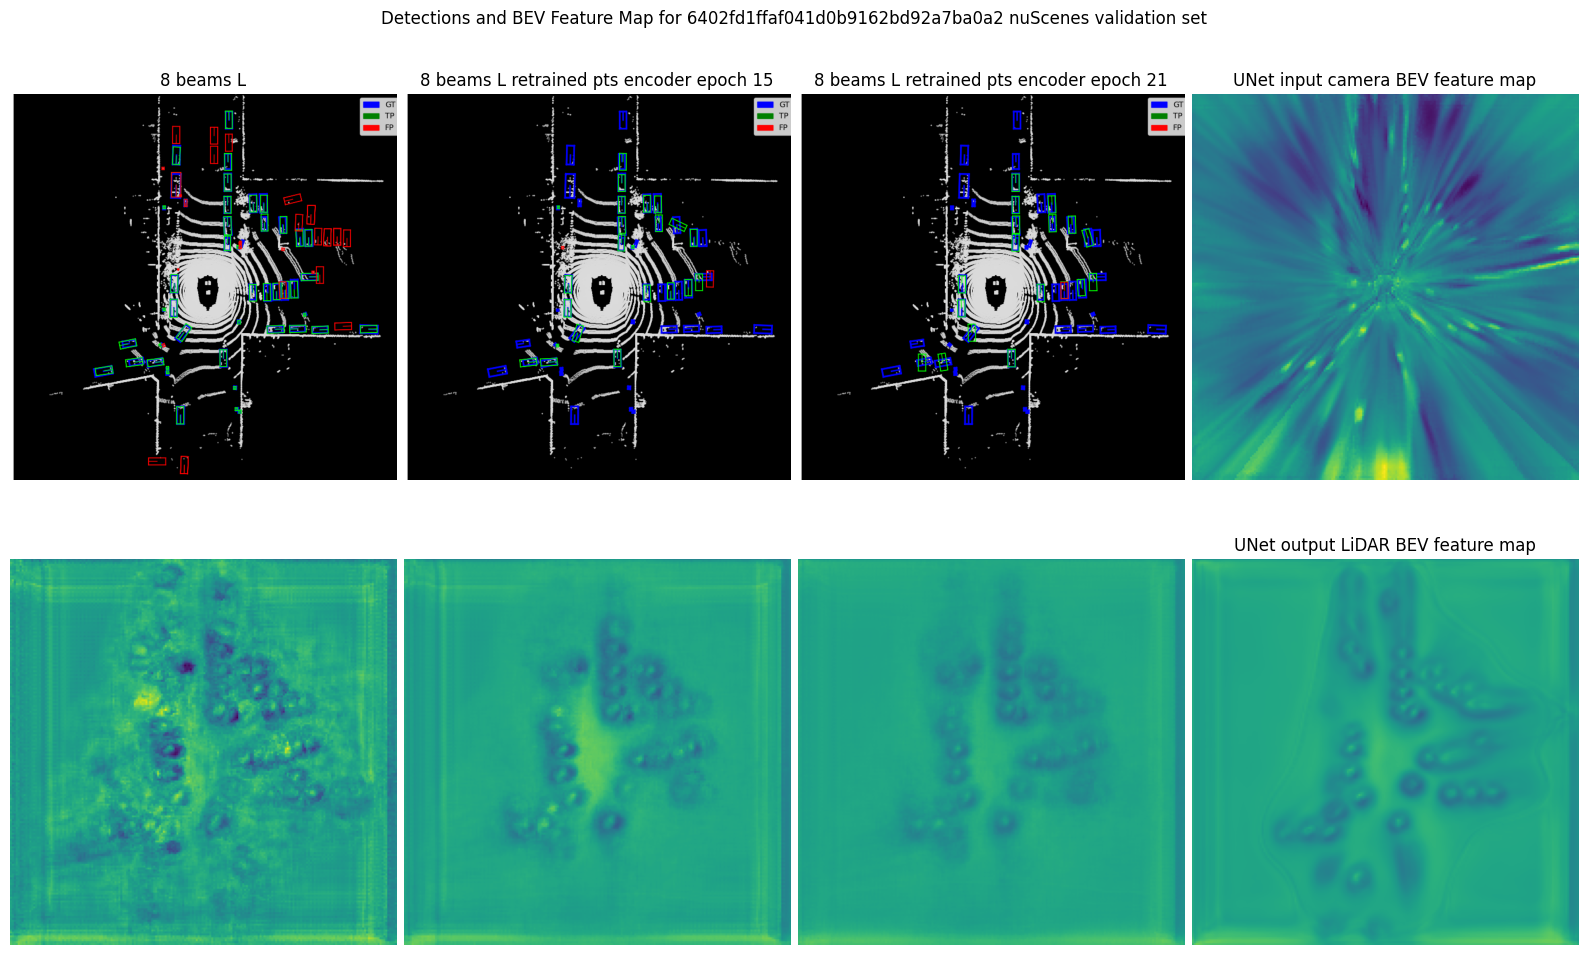

In [14]:
plot_detections_feature_maps(sample_token, 
                            nusc=[nusc_LC_32_beams, nusc_L_8_beams_retrained, nusc_L_8_beams_retrained_epoch_21], 
                            pts_bev_embed=[pts_bev_embed_8_beams, pts_bev_embed_retrained, pts_bev_embed_retrained_epoch_21, pts_bev_embed_unet_output],
                            img_bev_embed=img_bev_embed_input,
                            scaled=True,
                            custom_titles=[
                                f"Detections and BEV Feature Map for {sample_token} nuScenes validation set",
                                "8 beams L",
                                "8 beams L retrained pts encoder epoch 15",
                                "8 beams L retrained pts encoder epoch 21",
                                "UNet input camera BEV feature map",
                                "",
                                "",
                                "",
                                "UNet output LiDAR BEV feature map"
                            ],
                            channel=234,
                            reduction='none')

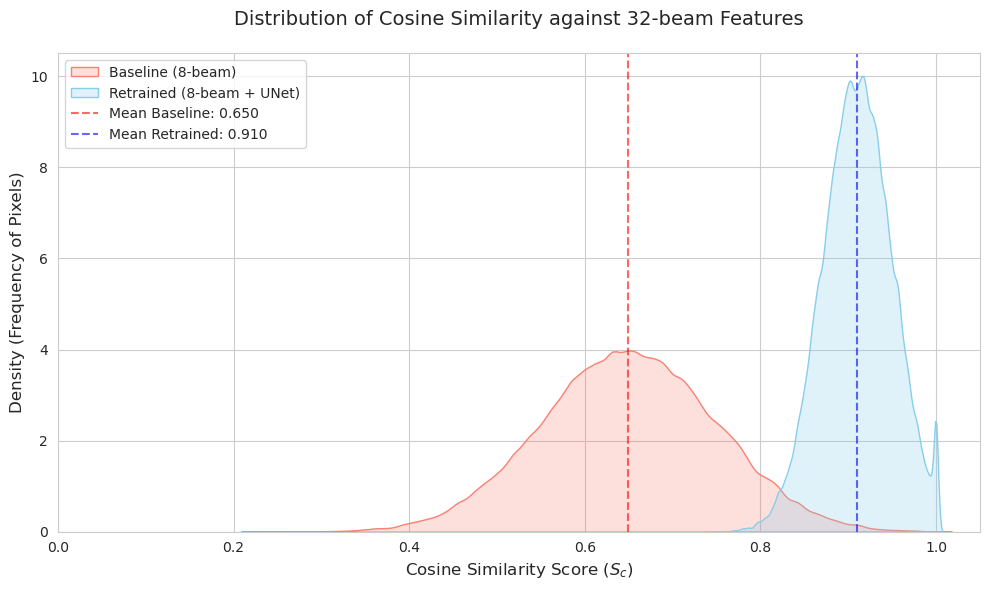

In [7]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_similarity_pdf(baseline_sim, retrained_sim, save_path="similarity_pdf.png"):
    """
    Args:
        baseline_sim (torch.Tensor): Shape (1, 200, 200) - Sim between 32-beam and 8-beam
        retrained_sim (torch.Tensor): Shape (1, 200, 200) - Sim between 32-beam and Retrained 8-beam
    """
    
    # 1. Flatten the tensors to 1D arrays (40,000 values each)
    # We use .cpu().numpy() to move data from GPU for plotting
    base_data = baseline_sim.detach().cpu().view(-1).numpy()
    # print(base_data.shape)
    train_data = retrained_sim.detach().cpu().view(-1).numpy()

    # 2. Setup the plot style
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # 3. Plot the Kernel Density Estimate (PDF)
    sns.kdeplot(base_data, fill=True, color="salmon", label="Baseline (8-beam)", bw_adjust=0.5)
    sns.kdeplot(train_data, fill=True, color="skyblue", label="Retrained (8-beam + UNet)", bw_adjust=0.5)

    # 4. Add vertical lines for the Means
    mean_base = np.mean(base_data)
    mean_train = np.mean(train_data)
    
    plt.axvline(mean_base, color='red', linestyle='--', alpha=0.6, 
                label=f'Mean Baseline: {mean_base:.3f}')
    plt.axvline(mean_train, color='blue', linestyle='--', alpha=0.6, 
                label=f'Mean Retrained: {mean_train:.3f}')

    # 5. Formatting for the Slide
    plt.title("Distribution of Cosine Similarity against 32-beam Features", fontsize=14, pad=20)
    plt.xlabel("Cosine Similarity Score ($S_c$)", fontsize=12)
    plt.ylabel("Density (Frequency of Pixels)", fontsize=12)
    plt.xlim(0, 1.05)  # Cosine sim is max 1.0
    plt.legend(loc="upper left")
    
    # 6. Save and Show
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300)
    plt.show()

# --- EXAMPLE USAGE ---
# Assuming you have your tensors from the validation loop:
# sim_tensor_base = F.cosine_similarity(feat_32, feat_8_base, dim=1) 
# sim_tensor_retrained = F.cosine_similarity(feat_32, feat_8_retrained, dim=1)

# Dummy data for demonstration:
sim_base = torch.normal(0.65, 0.1, (1, 200, 200)).clamp(0, 1)
sim_retrained = torch.normal(0.91, 0.04, (1, 200, 200)).clamp(0, 1)

plot_similarity_pdf(sim_base, sim_retrained)

In [108]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_similarity_histogram(baseline_sim, retrained_sim, bins=50, log_scale=True):
    # Flatten and move to CPU
    base_data = baseline_sim.detach().cpu().view(-1).numpy()
    train_data = retrained_sim.detach().cpu().view(-1).numpy()

    plt.figure(figsize=(12, 6))
    
    # Plotting Histograms with alpha (transparency) to see the overlap
    plt.hist(base_data, bins=bins, color='red', alpha=0.5, label='Baseline (8-beam)', edgecolor='black')
    plt.hist(train_data, bins=bins, color='blue', alpha=0.5, label='Retrained (8-beam + UNet)', edgecolor='black')

    if log_scale:
        plt.yscale('log')
        plt.ylabel("Number of Pixels (Log Scale)", fontsize=12)
    else:
        plt.ylabel("Number of Pixels (Count)", fontsize=12)

    plt.title("Frequency of Cosine Similarity Scores across BEV Grid", fontsize=14)
    plt.xlabel("Cosine Similarity Score", fontsize=12)
    plt.xlim(0, 1.0)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Example Usage:
# plot_similarity_histogram(sim_base, sim_retrained, log_scale=True)

In [12]:
pts_bev_embed_32_beams_all = []
pts_bev_embed_8_beams_all = []
pts_bev_embed_retrained_all = []
pts_bev_embed_unet_output_all = []
img_bev_embed_unet_input_all = []
for lidar_folder in lidar_folders:
    pts_bev_embed_32_beams_all.append(get_pts_embed(lidar_folder, root_32_beams).to('cpu'))
    pts_bev_embed_8_beams_all.append(get_pts_embed(lidar_folder, root_8_beams).to('cpu'))
    pts_bev_embed_retrained_all.append(get_pts_embed(lidar_folder, root_retrained).to('cpu'))
    data, img, _ = get_bev_prediction(lidar_folder, root_unet_output)
    img_bev_embed_unet_input_all.append(img.to('cpu'))
    pts_bev_embed_unet_output_all.append(data.to('cpu'))

# Stack all samples together
# This will create tensors of shape (num_samples, num_channels, height, width)
#   where num_samples is the number of lidar folders (samples)

pts_bev_embed_32_beams_all = torch.cat(pts_bev_embed_32_beams_all, dim=0)
pts_bev_embed_8_beams_all = torch.cat(pts_bev_embed_8_beams_all, dim=0)
pts_bev_embed_retrained_all = torch.cat(pts_bev_embed_retrained_all, dim=0) 
pts_bev_embed_unet_output_all = torch.cat(pts_bev_embed_unet_output_all, dim=0)   
img_bev_embed_unet_input_all = torch.cat(img_bev_embed_unet_input_all, dim=0)


Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_val_LC_full_mini_nuscenes/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984242447730/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_experiment/unibev_val_L_full_mini_nuscenes_8_beams/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984242447730/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded pts_bev_embed from /home/mingdayang/mmdetection3d//outputs/inference/L_encoder_retraining_experiment/19-03-2026_eval_nuscenes_val_L_8_beams_17-03-2026-01_UNetAttention_sampled_quarter_nuscenes_infos_temporal_train_nuscenes_infos_temporal_val_pts_encoder_retraining_only_mse_loss_epoch_15/n015-2018-10-08-15-36-50+0800__LIDAR_TOP__1538984242447730/vis_data.pt with shape torch.Size([1, 40000, 256])
Loaded bev_consumer_prediction from /home/mingdayang/mmdetection3d/outputs/inference/L_encoder_retraining_exper

In [13]:
from sklearn.decomposition import PCA
# First let's see how well feature map of 32 beams can be represented in 3 dimensions using PCA and how the predicted Unet performs
pca_32 = PCA(n_components=3)
pts_bev_embed_32_beams_all_pca = pca_32.fit_transform((einops.rearrange(pts_bev_embed_32_beams_all.cpu().numpy(), 'b c h w -> (b h w) c')))
pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))

pts_bev_embed_32_beams_all_pca = einops.rearrange((pts_bev_embed_32_beams_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_32_beams_all.shape[0], h=200, w=200)
pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)

In [89]:
print(img_bev_embed_unet_input_all.shape)

torch.Size([81, 256, 200, 200])


In [91]:
pca_img = PCA(n_components=3)
img_bev_embed_unet_input_all_pca = pca_img.fit_transform((einops.rearrange(img_bev_embed_unet_input_all.cpu().numpy(), 'b c h w -> (b h w) c')))
img_bev_embed_unet_input_all_pca = einops.rearrange((img_bev_embed_unet_input_all_pca), '(b h w) c -> b c h w', b=img_bev_embed_unet_input_all.shape[0], h=200, w=200)


KeyboardInterrupt: 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(81, 3, 200, 200)


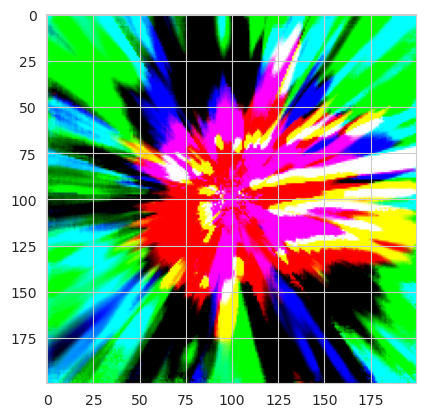

In [93]:
print(img_bev_embed_unet_input_all_pca.shape)

plt.imshow(einops.rearrange(img_bev_embed_unet_input_all_pca, 'b c h w -> b h w c')[30][:,:,:])

In [61]:
# ...existing code...
from nuscenes.eval.common.utils import boxes_to_sensor
from matplotlib.patches import Polygon
from nuscenes.eval.common.data_classes import EvalBoxes
from pyquaternion import Quaternion
from nuscenes.eval.common.utils import boxes_to_sensor, center_distance

def get_boxes_conf_th(gt_boxes, pred_boxes, class_names, dist_fcn_callable, conf_th=0.15, dist_th=2):
    filter_boxes_list = []
    for class_name in class_names:
        f1_score_list_per_class = []
        boxes_list_per_class = []
        npos = len([1 for gt_box in gt_boxes if gt_box.detection_name == class_name])
        pred_boxes_list = [box for box in pred_boxes if box.detection_name == class_name]
        pred_boxes_list = [box for box in pred_boxes_list if box.detection_score > conf_th]
        pred_confs = [box.detection_score for box in pred_boxes_list]
        sortind = [i for (v, i) in sorted((v, i) for (i, v) in enumerate(pred_confs))][::-1]

        tp = []  # Accumulator of true positives.
        fp = []  # Accumulator of false positives.

        taken = set()
        tp_boxes = []
        fp_boxes = []
        for ind in sortind:
            pred_box = pred_boxes_list[ind]
            min_dist = np.inf
            match_gt_idx = None

            for gt_idx, gt_box in enumerate(gt_boxes):
                if gt_box.detection_name == class_name and not gt_idx in taken:
                    this_distance = dist_fcn_callable(gt_box, pred_box)
                    if this_distance < min_dist:
                        min_dist = this_distance
                        match_gt_idx = gt_idx

            is_match = min_dist < dist_th

            if is_match:
                taken.add(match_gt_idx)
                tp_boxes.append(pred_box)
                tp.append(1)
                fp.append(0)
            else:
                tp.append(0)
                fp.append(1)
                fp_boxes.append(pred_box)

        filter_boxes_list.append(dict(class_name= class_name,
                                      tp_boxes = tp_boxes,
                                      fp_boxes = fp_boxes))

    return filter_boxes_list


def _metric_to_pixel(xy, x_range, y_range, w, h, flip_y=True):
    px = (xy[..., 0] - x_range[0]) / (x_range[1] - x_range[0]) * (w - 1)
    py = (xy[..., 1] - y_range[0]) / (y_range[1] - y_range[0]) * (h - 1)
    if flip_y:
        py = (h - 1) - py
    return np.stack([px, py], axis=-1)

def _box_to_bev_polygon_and_front(box, x_range=(-50, 50), y_range=(-50, 50), w=200, h=200, flip_y=True):
    cx, cy = box.center[0], box.center[1]
    width, length = box.wlh[0], box.wlh[1]
    yaw = Quaternion(box.orientation).yaw_pitch_roll[0]

    dx = length / 2.0
    dy = width / 2.0

    corners_local = np.array([
        [ dx,  dy],   # front-left
        [ dx, -dy],   # front-right
        [-dx, -dy],   # rear-right
        [-dx,  dy],   # rear-left
    ])

    c, s = np.cos(yaw), np.sin(yaw)
    R = np.array([[c, -s],
                  [s,  c]])

    corners = corners_local @ R.T
    corners[:, 0] += cx
    corners[:, 1] += cy

    # Front edge
    f0, f1 = corners[0], corners[1]
    front_mid = 0.5 * (f0 + f1)

    # Inward direction: from front edge toward box center
    box_center_xy = np.array([cx, cy], dtype=np.float32)
    inward = box_center_xy - front_mid
    inward = inward / (np.linalg.norm(inward) + 1e-8)

    # Stripe starts at edge and goes inside
    stripe_len = 0.35 * length
    front_a = front_mid
    front_b = front_mid + stripe_len * inward

    poly_px = _metric_to_pixel(corners, x_range, y_range, w, h, flip_y=flip_y)
    front_px = _metric_to_pixel(np.stack([front_a, front_b], axis=0), x_range, y_range, w, h, flip_y=flip_y)
    return poly_px, front_px

def plot_pca_with_boxes_from_vis(
    nusc_vis,
    sample_token,
    tensor,
    title=None,
    conf_th=0.15,
    with_GT=True,
    x_range=(-50, 50),
    y_range=(-50, 50),
):
    feat = tensor
    if hasattr(feat, "detach"):
        feat = feat.detach().cpu().numpy()

    if feat.ndim == 4:
        feat = feat[0]
    if feat.ndim == 3 and feat.shape[0] == 3:
        img = np.transpose(feat, (1, 2, 0))
    elif feat.ndim == 3 and feat.shape[-1] == 3:
        img = feat
    elif feat.ndim == 2:
        img = feat
    else:
        raise ValueError(f"Not an option, got shape {feat.shape}")

    # img = img - img.min()
    # img = img / (img.max() + 1e-6)

    sample_rec = nusc_vis.nusc.get("sample", sample_token)
    sd_record = nusc_vis.nusc.get("sample_data", sample_rec["data"]["LIDAR_TOP"])
    cs_record = nusc_vis.nusc.get("calibrated_sensor", sd_record["calibrated_sensor_token"])
    pose_record = nusc_vis.nusc.get("ego_pose", sd_record["ego_pose_token"])

    boxes_gt_global = nusc_vis.gt_boxes[sample_token] if with_GT else []
    boxes_est_global = nusc_vis.pred_boxes[sample_token]

    boxes_gt = boxes_to_sensor(boxes_gt_global, pose_record, cs_record) if with_GT else []
    boxes_est = boxes_to_sensor(boxes_est_global, pose_record, cs_record)

    predict_boxes = get_boxes_conf_th(
        boxes_gt_global,
        boxes_est_global,
        nusc_vis.cfg.class_names,
        center_distance,
        conf_th=conf_th,
        dist_th=2,
    )

    tp_predict_boxes, fp_predict_boxes = [], []
    for pred_boxes_cls in predict_boxes:
        tp_predict_boxes.extend(pred_boxes_cls["tp_boxes"])
        fp_predict_boxes.extend(pred_boxes_cls["fp_boxes"])

    tp_boxes_est = boxes_to_sensor(tp_predict_boxes, pose_record, cs_record)
    fp_boxes_est = boxes_to_sensor(fp_predict_boxes, pose_record, cs_record)

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(img, origin="upper")
    ax.set_xlim(0, img.shape[1] - 1)
    ax.set_ylim(img.shape[0] - 1, 0)
    ax.set_title(title or f"PCA + boxes for {sample_token}")
    ax.axis("off")

    def draw_boxes(boxes, color):
        for box in boxes:
            poly, front = _box_to_bev_polygon_and_front(
                box,
                x_range=x_range,
                y_range=y_range,
                w=img.shape[1],
                h=img.shape[0],
                flip_y=True,  # set False only if you removed tensor flip in your loader
            )
            ax.add_patch(Polygon(poly, closed=True, fill=False, edgecolor=color, linewidth=1.5))
            ax.plot(front[:, 0], front[:, 1], color=color, linewidth=2.0, solid_capstyle="round")

# ...existing code...

    if with_GT:
        draw_boxes(boxes_gt, "blue")
    draw_boxes(tp_boxes_est, "lime")
    draw_boxes(fp_boxes_est, "red")

    plt.tight_layout()
    plt.show()

['n015-2018-10-08-15-36-50+0800', 'LIDAR_TOP', '1538984239948316']
1538984239948316
1538984239948316
Closest sample token: 61a7bd24f88a46c2963280d8b13ac675
Time difference (microseconds): 0
torch.Size([200, 200])


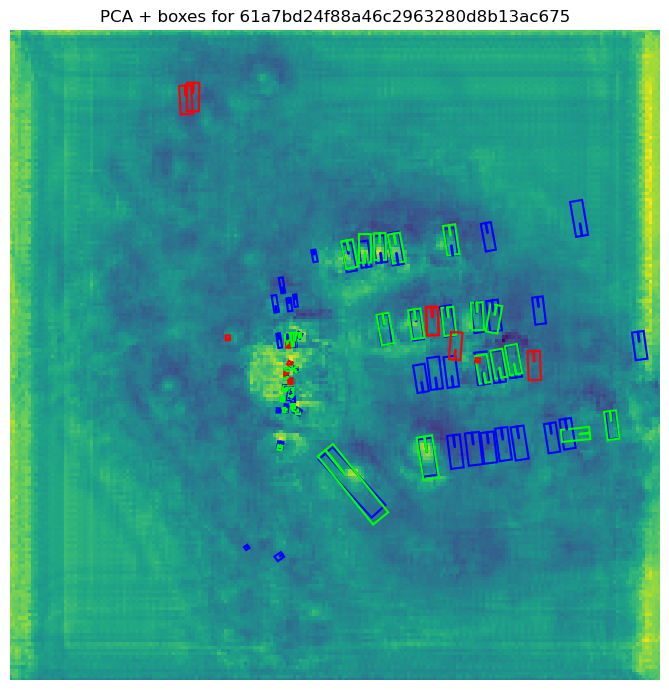

In [64]:
idx=30
sample_token = find_sample_token(lidar_folders[idx])
feature_tensor = einops.rearrange(pts_bev_embed_8_beams_all, 'b c h w -> b h w c')[idx][:,:,:]
feature_tensor = einops.reduce(feature_tensor, 'h w c -> h w', 'mean')
print(feature_tensor.shape)
plot_pca_with_boxes_from_vis(
    nusc_vis=nusc_L_8_beams,
    sample_token=sample_token,
    tensor=feature_tensor,
    conf_th=0.15,
    with_GT=True,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


['n015-2018-10-08-15-36-50+0800', 'LIDAR_TOP', '1538984239948316']
1538984239948316
1538984239948316
Closest sample token: 61a7bd24f88a46c2963280d8b13ac675
Time difference (microseconds): 0
Rendering sample token 61a7bd24f88a46c2963280d8b13ac675


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Rendering sample token 61a7bd24f88a46c2963280d8b13ac675


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


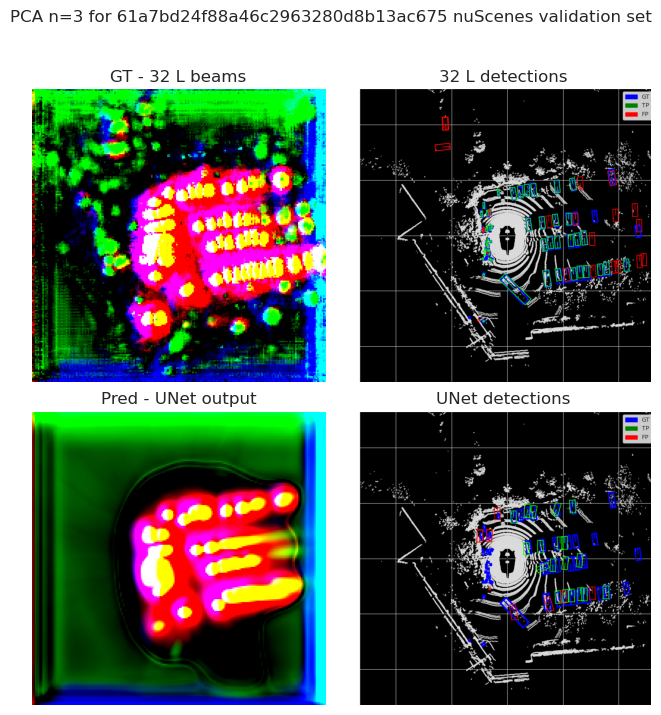

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(8,8),  gridspec_kw={"wspace": 0.1, "hspace": 0.1})
# fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

# pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))
# pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)
vmin = min(pts_bev_embed_32_beams_all_pca.min().item(), pts_bev_embed_unet_output_all_pca.min().item())
vmax = max(pts_bev_embed_32_beams_all_pca.max().item(), pts_bev_embed_unet_output_all_pca.max().item())
idx=30
sample_token = find_sample_token(lidar_folders[idx])
plt.suptitle(f"PCA n=3 for {sample_token} nuScenes validation set", fontsize=12)
ax[0,0].imshow(einops.rearrange(pts_bev_embed_32_beams_all_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[0,0].set_title("GT - 32 L beams")
ax[0,0].axis('off')



ax[1,0].imshow(einops.rearrange(pts_bev_embed_unet_output_all_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[1,0].set_title("Pred - UNet output")
ax[1,0].axis('off')


sample_fig = nusc_unet_only_output.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[1,1].imshow(sample_image)
ax[1,1].set_title(f"UNet detections")
ax[1,1].axis('off')
ax[1,1].set_ylim(800, 106)
ax[1,1].set_xlim(106, 800)
plt.tight_layout()
plt.close(sample_fig)


sample_fig = nusc_L_32_beams.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[0,1].imshow(sample_image)
ax[0,1].set_title(f"32 L detections")
ax[0,1].axis('off')
ax[0,1].set_ylim(800, 106)
ax[0,1].set_xlim(106, 800)
plt.tight_layout()
plt.close(sample_fig)
plt.show()

Rendering sample token 61a7bd24f88a46c2963280d8b13ac675
Rendering sample token 61a7bd24f88a46c2963280d8b13ac675
Rendering sample token 61a7bd24f88a46c2963280d8b13ac675


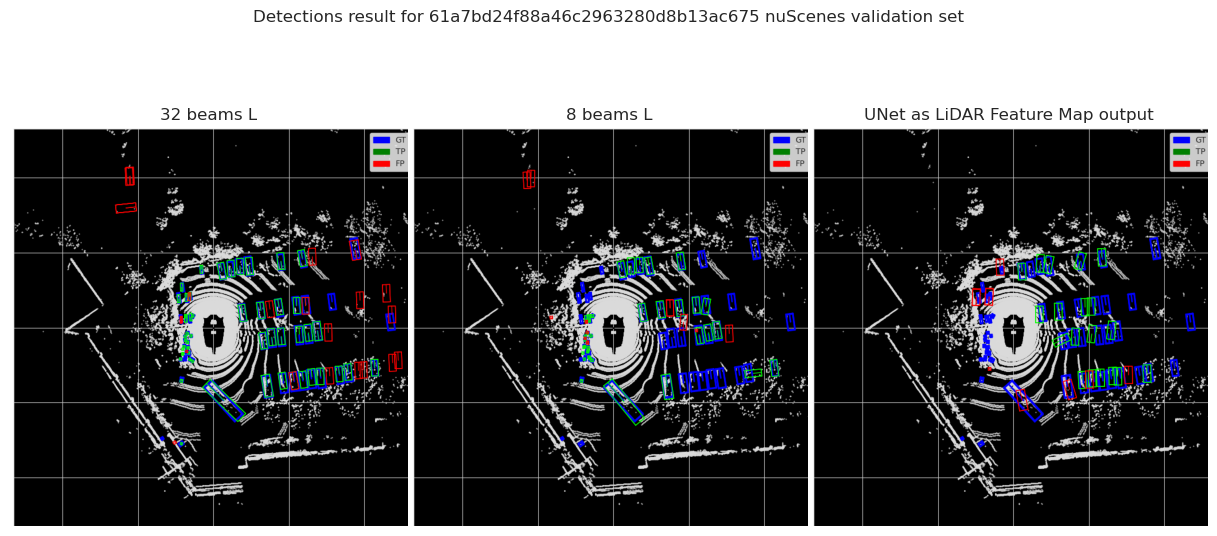

In [97]:
# sample_token = sample_tokens[0]
# print(sample_token)
custom_titles = [
    f"Detections result for {sample_token} nuScenes validation set",
    "32 beams L",
    "8 beams L",
    "UNet as LiDAR Feature Map output"
]
plot_GT_pred_pointcloud(sample_token, 
                        nusc_1=nusc_L_32_beams, 
                        nusc_2=nusc_L_8_beams,
                        nusc_3=nusc_unet_only_output,
                        custom_titles=custom_titles)

In [ ]:
from sklearn.decomposition import PCA
# First let's see how well feature map of 32 beams can be represented in 3 dimensions using PCA and how the predicted Unet performs
pca_8 = PCA(n_components=3)
pts_bev_embed_8_beams_all_pca = pca_8.fit_transform((einops.rearrange(pts_bev_embed_8_beams_all.cpu().numpy(), 'b c h w -> (b h w) c')))
pts_bev_embed_retrained_pca = pca_8.transform((einops.rearrange(pts_bev_embed_retrained_all.cpu().numpy(), 'b c h w -> (b h w) c')))

pts_bev_embed_retrained_pca = einops.rearrange((pts_bev_embed_retrained_pca), '(b h w) c -> b c h w', b=pts_bev_embed_retrained_all.shape[0], h=200, w=200)
pts_bev_embed_8_beams_all_pca = einops.rearrange((pts_bev_embed_8_beams_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_8_beams_all.shape[0], h=200, w=200)

EinopsError:  Error while processing rearrange-reduction pattern "(b h w) c -> b c h w".
 Input tensor shape: (81, 3, 200, 200). Additional info: {'b': 81, 'h': 200, 'w': 200}.
 Expected 2 dimensions, got 4

In [37]:
pts_bev_embed_8_beams_all_pca = einops.rearrange((pts_bev_embed_8_beams_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_8_beams_all.shape[0], h=200, w=200)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


['n015-2018-10-08-15-36-50+0800', 'LIDAR_TOP', '1538984251447166']
1538984251447166
1538984251447166
Closest sample token: e6e877f31dd447199b56cae07f86daad
Time difference (microseconds): 0
Rendering sample token e6e877f31dd447199b56cae07f86daad


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


Rendering sample token e6e877f31dd447199b56cae07f86daad


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


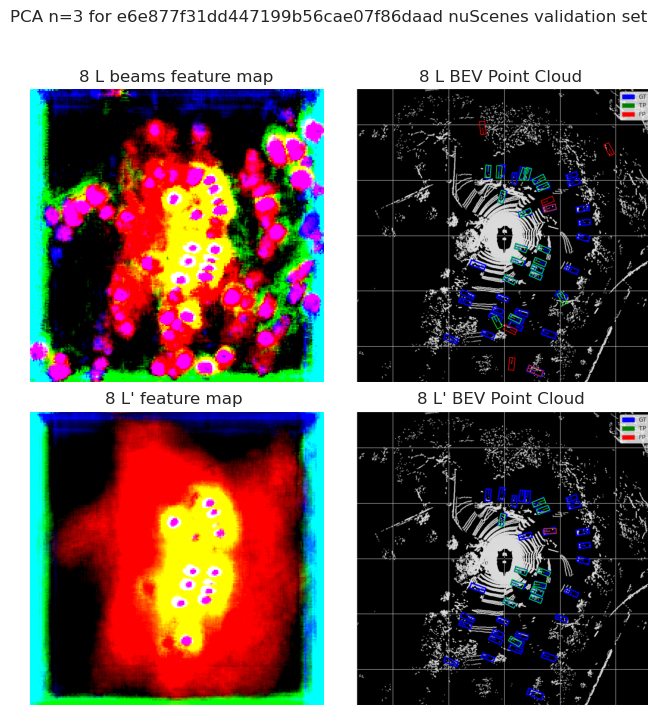

In [45]:
# fig, ax = plt.subplots(1, 2, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
# fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

# pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))
# pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)
fig, ax = plt.subplots(2, 2, figsize=(8,8),  gridspec_kw={"wspace": 0.1, "hspace": 0.1})
# fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

# pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))
# pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)
vmin = min(pts_bev_embed_8_beams_all_pca.min().item(), pts_bev_embed_retrained_pca.min().item())
vmax = max(pts_bev_embed_8_beams_all_pca.max().item(), pts_bev_embed_retrained_pca.max().item())
idx=20
sample_token = find_sample_token(lidar_folders[idx])
plt.suptitle(f"PCA n=3 for {sample_token} nuScenes validation set", fontsize=12)
ax[0,0].imshow(einops.rearrange(pts_bev_embed_8_beams_all_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[0,0].set_title("8 L beams feature map")
ax[0,0].axis('off')



ax[1,0].imshow(einops.rearrange(pts_bev_embed_retrained_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[1,0].set_title("8 L' feature map ")
ax[1,0].axis('off')


sample_fig = nusc_L_8_beams_retrained.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[1,1].imshow(sample_image)
ax[1,1].set_title(f"8 L' BEV Point Cloud")
ax[1,1].axis('off')
ax[1,1].set_ylim(800, 106)
ax[1,1].set_xlim(106, 800)
plt.tight_layout()
plt.close(sample_fig)


sample_fig = nusc_L_8_beams.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[0,1].imshow(sample_image)
ax[0,1].set_title(f"8 L BEV Point Cloud")
ax[0,1].axis('off')
ax[0,1].set_ylim(800, 106)
ax[0,1].set_xlim(106, 800)
plt.tight_layout()
plt.close(sample_fig)
# plt.show()
plt.show()

In [48]:
from sklearn.decomposition import PCA
# First let's see how well feature map of 32 beams can be represented in 3 dimensions using PCA and how the predicted Unet performs
pca_32 = PCA(n_components=3)
pts_bev_embed_32_beams_all_pca = pca_32.fit_transform((einops.rearrange(pts_bev_embed_32_beams_all.cpu().numpy(), 'b c h w -> (b h w) c')))
pts_bev_embed_retrained_pca = pca_32.transform((einops.rearrange(pts_bev_embed_retrained_all.cpu().numpy(), 'b c h w -> (b h w) c')))
pst_bev_embed_8_beams_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_8_beams_all.cpu().numpy(), 'b c h w -> (b h w) c')))

pts_bev_embed_retrained_pca = einops.rearrange((pts_bev_embed_retrained_pca), '(b h w) c -> b c h w', b=pts_bev_embed_retrained_all.shape[0], h=200, w=200)
pts_bev_embed_32_beams_all_pca = einops.rearrange((pts_bev_embed_32_beams_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_32_beams_all.shape[0], h=200, w=200)
pts_bev_embed_8_beams_all_pca = einops.rearrange((pst_bev_embed_8_beams_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_8_beams_all.shape[0], h=200, w=200)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


['n015-2018-10-08-15-36-50+0800', 'LIDAR_TOP', '1538984241947812']
1538984241947812
1538984241947812
Closest sample token: b6c420c3a5bd4a219b1cb82ee5ea0aa7
Time difference (microseconds): 0
Rendering sample token b6c420c3a5bd4a219b1cb82ee5ea0aa7
Rendering sample token b6c420c3a5bd4a219b1cb82ee5ea0aa7
Rendering sample token b6c420c3a5bd4a219b1cb82ee5ea0aa7


/home/mingdayang/miniconda3/envs/unibev/lib/python3.7/site-packages/ipykernel_launcher.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


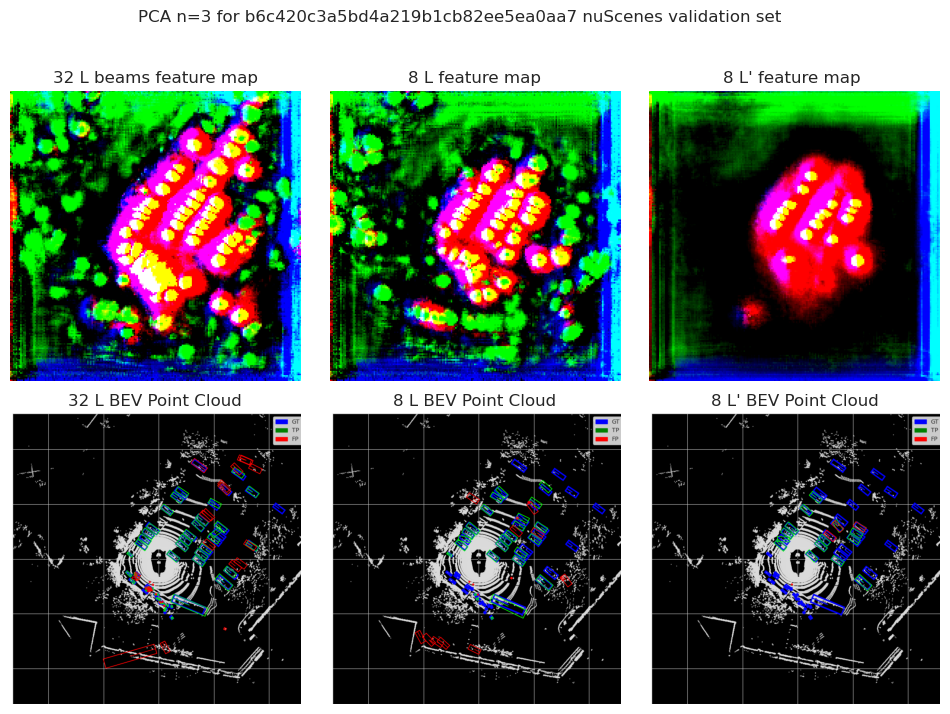

In [57]:
# fig, ax = plt.subplots(1, 2, figsize=(12,6),  gridspec_kw={"wspace": 0.02, "hspace": 0.02})
# fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

# pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))
# pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)
fig, ax = plt.subplots(2, 3, figsize=(12,8),  gridspec_kw={"wspace": 0.1, "hspace": 0.1})
# fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.90, wspace=0.02, hspace=0.005)

# pts_bev_embed_unet_output_all_pca = pca_32.transform((einops.rearrange(pts_bev_embed_unet_output_all.cpu().numpy(), 'b c h w -> (b h w) c')))
# pts_bev_embed_unet_output_all_pca = einops.rearrange((pts_bev_embed_unet_output_all_pca), '(b h w) c -> b c h w', b=pts_bev_embed_unet_output_all.shape[0], h=200, w=200)
vmin = min(pts_bev_embed_32_beams_all_pca.min().item(), pts_bev_embed_retrained_pca.min().item())
vmax = max(pts_bev_embed_32_beams_all_pca.max().item(), pts_bev_embed_retrained_pca.max().item())
idx=40
sample_token = find_sample_token(lidar_folders[idx])
plt.suptitle(f"PCA n=3 for {sample_token} nuScenes validation set", fontsize=12)
ax[0,0].imshow(einops.rearrange(pts_bev_embed_32_beams_all_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[0,0].set_title("32 L beams feature map")
ax[0,0].axis('off')



ax[0,2].imshow(einops.rearrange(pts_bev_embed_retrained_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[0,2].set_title("8 L' feature map ")
ax[0,2].axis('off')

ax[0,1].imshow(einops.rearrange(pts_bev_embed_8_beams_all_pca, 'b c h w -> b h w c')[idx][:,:,:], vmin=vmin, vmax=vmax)
ax[0,1].set_title("8 L feature map")
ax[0,1].axis('off')

sample_fig = nusc_L_32_beams.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[1,0].imshow(sample_image)
ax[1,0].set_title(f"32 L BEV Point Cloud")
ax[1,0].axis('off')
ax[1,0].set_ylim(800, 106)
ax[1,0].set_xlim(106, 800)
plt.close(sample_fig)


sample_fig = nusc_L_8_beams.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[1,1].imshow(sample_image)
ax[1,1].set_title(f"8 L BEV Point Cloud")
ax[1,1].axis('off')
ax[1,1].set_ylim(800, 106)
ax[1,1].set_xlim(106, 800)
plt.close(sample_fig)

sample_fig = nusc_L_8_beams_retrained.main_vis_per_sample(sample_token, conf_th=0.15, with_GT=True, display_legend=True)
sample_image = figure_to_image(sample_fig)
ax[1,2].imshow(sample_image)
ax[1,2].set_title(f"8 L' BEV Point Cloud")
ax[1,2].axis('off')
ax[1,2].set_ylim(800, 106)
ax[1,2].set_xlim(106, 800)
plt.close(sample_fig)
plt.tight_layout()
# plt.show()
plt.show()

torch.Size([81, 200, 200])
torch.Size([81, 200, 200])
(3240000,)


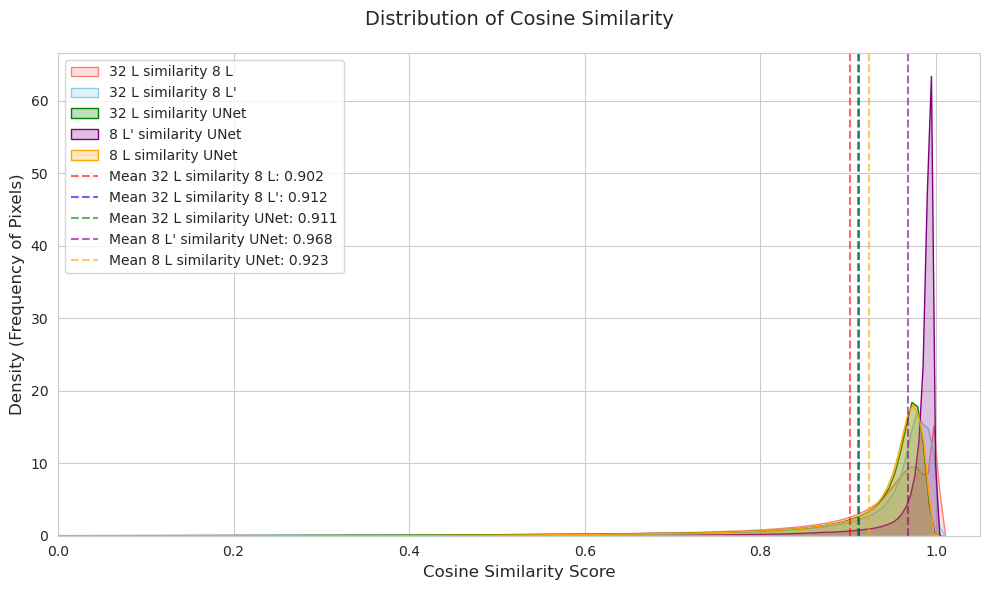

In [ ]:
import seaborn as sns


cosine_fn = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
similarity_32_8 = cosine_fn(pts_bev_embed_32_beams_all, pts_bev_embed_8_beams_all)
similarity_32_retrained = cosine_fn(pts_bev_embed_32_beams_all, pts_bev_embed_retrained_all)
similarity_32_unet = cosine_fn(pts_bev_embed_32_beams_all, pts_bev_embed_unet_output_all)
similarity_retrained_unet = cosine_fn(pts_bev_embed_retrained_all, pts_bev_embed_unet_output_all)
similarity_8_unet = cosine_fn(pts_bev_embed_8_beams_all, pts_bev_embed_unet_output_all)

print(similarity_32_8.shape)
print(similarity_32_retrained.shape)

# 1. Flatten the tensors to 1D arrays (40,000 values each)
# We use .cpu().numpy() to move data from GPU for plotting
similarity_32_8 = similarity_32_8.detach().cpu().view(-1).numpy()
print(similarity_32_8.shape)
# print(base_data.shape)
similarity_32_retrained = similarity_32_retrained.detach().cpu().view(-1).numpy()
similarity_32_unet = similarity_32_unet.detach().cpu().view(-1).numpy()
similarity_retrained_unet = similarity_retrained_unet.detach().cpu().view(-1).numpy()
similarity_8_unet = similarity_8_unet.detach().cpu().view(-1).numpy()
# 2. Setup the plot style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Plot the Kernel Density Estimate (PDF)
sns.kdeplot(similarity_32_8, fill=True, color="salmon", label="32 L similarity 8 L", bw_adjust=0.5)
sns.kdeplot(similarity_32_retrained, fill=True, color="skyblue", label="32 L similarity 8 L'", bw_adjust=0.5)
sns.kdeplot(similarity_32_unet, fill=True, color="green", label="32 L similarity UNet", bw_adjust=0.5)
sns.kdeplot(similarity_retrained_unet, fill=True, color="purple", label="8 L' similarity UNet", bw_adjust=0.5)
sns.kdeplot(similarity_8_unet, fill=True, color="orange", label="8 L similarity UNet", bw_adjust=0.5)

# 4. Add vertical lines for the Means
mean_32_8 = np.mean(similarity_32_8)
mean_32_retrained = np.mean(similarity_32_retrained)
mean_32_unet = np.mean(similarity_32_unet)
mean_retrained_unet = np.mean(similarity_retrained_unet)
mean_8_unet = np.mean(similarity_8_unet)


plt.axvline(mean_32_8, color='red', linestyle='--', alpha=0.6, 
            label=f'Mean 32 L similarity 8 L: {mean_32_8:.3f}')
plt.axvline(mean_32_retrained, color='blue', linestyle='--', alpha=0.6, 
            label=f'Mean 32 L similarity 8 L\': {mean_32_retrained:.3f}')
plt.axvline(mean_32_unet, color='green', linestyle='--', alpha=0.6,
            label=f'Mean 32 L similarity UNet: {mean_32_unet:.3f}')
plt.axvline(mean_retrained_unet, color='purple', linestyle='--', alpha=0.6,
            label=f'Mean 8 L\' similarity UNet: {mean_retrained_unet:.3f}')
plt.axvline(mean_8_unet, color='orange', linestyle='--', alpha=0.6,
            label=f'Mean 8 L similarity UNet: {mean_8_unet:.3f}')

# 5. Formatting for the Slide
plt.title("Distribution of Cosine Similarity", fontsize=14, pad=20)
plt.xlabel("Cosine Similarity Score", fontsize=12)
plt.ylabel("Density (Frequency of Pixels)", fontsize=12)
plt.xlim(0.0, 1.05)  # Cosine sim is max 1.0
# plt.ylim(0, 20)
plt.legend(loc="upper left")

# 6. Save and Show
plt.tight_layout()
# plt.savefig(save_path, dpi=300)
plt.show()

# plot_similarity_pdf(similarity_32_8, similarity_32_retrained)
# plot_similarity_histogram(similarity_32_8, similarity_32_retrained, log_scale=True)




mse_fn = torch.nn.MSELoss()
mse_loss_32_vs_unet = mse_fn(pts_bev_embed_8_beams_all.to('cpu'), pts_bev_embed_retrained_all.cpu())
# print(f"MSE Loss between UNet output and 32 beams: {mse_loss_32_vs_unet.item()}")
# print(f"RMSE Loss between UNet output and 32 beams: {torch.sqrt(mse_loss_32_vs_unet).item()}")

# # l1_fn = torch.nn.L1Loss()
# # l1_loss_32_vs_unet = l1_fn(pts_bev_embed_unet_output, pts_bev_embed_32_beams)

# print(f"L1 Loss between UNet output and 32 beams: {l1_loss_32_vs_unet.item()}")

In [34]:
mse_fn = torch.nn.MSELoss()
mse_loss_32_vs_unet_output = mse_fn(pts_bev_embed_unet_output_all, pts_bev_embed_32_beams_all)
print(f"MSE Loss between UNet output and 32 beams: {mse_loss_32_vs_unet_output.item()}")
mse_loss_retrained_vs_unet_output = mse_fn(pts_bev_embed_unet_output_all, pts_bev_embed_retrained_all)
print(f"MSE Loss between UNet output and retrained 8 beams pts encoder: {mse_loss_retrained_vs_unet_output.item()}")

error = pts_bev_embed_32_beams - pts_bev_embed_unet_output

error = torch.mean(error, dim=1)  # Average over channels to get a single error map
plt.imshow(error.cpu().numpy()[0])

MSE Loss between UNet output and 32 beams: 0.07478281855583191
MSE Loss between UNet output and retrained 8 beams pts encoder: 0.022363239899277687


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cuda:1!

# RP curve generation
Run file under to generate figures / graphs

In [ ]:
# from nuscenes.eval.detection.evaluate import NuScenesEval

# nusc_eval = NuScenesEval(
#     nusc,
#     config=eval_detect_configs,
#     result_path=results_L_8_beams_retrained,
#     eval_set="val",
#     output_dir=results_dir_L_8_beams_retrained
# )

In [ ]:
# nusc_eval.main()